In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)

### Create a fake dataset 

This dataset is a simple polynomial regression problem with a small it of noise

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

In [3]:
target_species = 4
species_threshold = 0.2

rolling_species_count = rd.Expr.select("count.species").rolling(25).mean()
err = rd.Expr.select("count.species").error(target_species) * 0.01

### Create the engine

This engine evolves `rd.Graph`s to fit the polynomial regression problem. The vertices of the graph are only allowed to use addition, multiplication, and constants. The engine also tracks the species count and species threshold as metrics, and uses the NEAT distance as a diversity metric.

In [4]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(
        rd.NeatDistance(),
        species_threshold=species_threshold,
        target_species=target_species,
    )
    .metrics(species_rolling=rolling_species_count, error=err)
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-06-09T01:03:45.981313Z  INFO Epoch 1    | Score:   2.0038 | Time: 213.50µs
2026-06-09T01:03:45.981453Z  INFO Epoch 2    | Score:   1.6821 | Time: 306.58µs
2026-06-09T01:03:45.981588Z  INFO Epoch 3    | Score:   1.6821 | Time: 406.58µs
2026-06-09T01:03:45.981704Z  INFO Epoch 4    | Score:   1.6821 | Time: 493.21µs
2026-06-09T01:03:45.981834Z  INFO Epoch 5    | Score:   1.6821 | Time: 588.21µs
2026-06-09T01:03:45.981984Z  INFO Epoch 6    | Score:   1.6821 | Time: 705.42µs
2026-06-09T01:03:45.982095Z  INFO Epoch 7    | Score:   1.6821 | Time: 789.13µs
2026-06-09T01:03:45.982212Z  INFO Epoch 8    | Score:   1.6821 | Time: 874.54µs
2026-06-09T01:03:45.982322Z  INFO Epoch 9    | Score:   1.6821 | Time: 958.84µs
2026-06-09T01:03:45.982434Z  INFO Epoch 10   | Score:   1.6821 | Time: 1.04ms
2026-06-09T01:03:45.982554Z  INFO Epoch 11   | Score:   1.6821 | Time: 1.13ms
2026-06-09T01:03:45.982662Z  INFO Epoch 12   | Score:   1.6821 | Time: 1.21ms
2026-06-09T01:03:45.982796Z  INFO Epoch 13   |

### Metrics

Using the `rd.MetricCollector` we can aggregate the metrics for the whole engine's run and visualize the metrics we want to track here once the engine has finished. In this case we only want to see our three expressions, but we could also see any `rd.Metric` that the engine tracks - refer to the docs for more details.

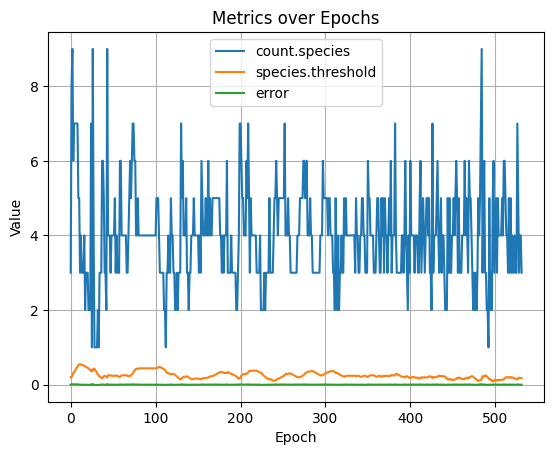

In [5]:
collector.plot(
    "count.species", "species.threshold", "error"
)  # , "species_rolling", "species_count_error", "err")
# collector.plot("err")

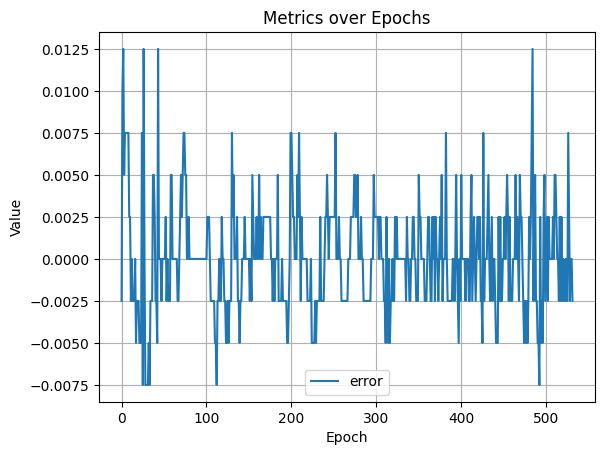

In [6]:
collector.plot("error")

In [7]:
df = collector.to_polars()
df.filter(pl.col("name") == "count.species").tail(20)
# df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.species""",5.0,2051.0,3.998051,1.280105,1.638668,2.825188,1.0,9.0,513,null,null,null,null,null,null,512,1,"[""species"", ""statistic""]"
"""count.species""",4.0,2055.0,3.998055,1.278856,1.635474,2.840932,1.0,9.0,514,null,null,null,null,null,null,513,1,"[""species"", ""statistic""]"
"""count.species""",4.0,2059.0,3.998058,1.277612,1.632292,2.856801,1.0,9.0,515,null,null,null,null,null,null,514,1,"[""species"", ""statistic""]"
"""count.species""",3.0,2062.0,3.996124,1.277127,1.631053,2.874819,1.0,9.0,516,null,null,null,null,null,null,515,1,"[""species"", ""statistic""]"
"""count.species""",5.0,2067.0,3.998066,1.276652,1.629841,2.862249,1.0,9.0,517,null,null,null,null,null,null,516,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.species""",5.0,2110.0,3.996212,1.275958,1.628069,2.92118,1.0,9.0,528,null,null,null,null,null,null,527,1,"[""species"", ""statistic""]"
"""count.species""",3.0,2113.0,3.994329,1.275485,1.626862,2.938951,1.0,9.0,529,null,null,null,null,null,null,528,1,"[""species"", ""statistic""]"
"""count.species""",4.0,2117.0,3.99434,1.274279,1.623786,2.955012,1.0,9.0,530,null,null,null,null,null,null,529,1,"[""species"", ""statistic""]"


In [8]:
df.filter(pl.col("name") == "error").tail(20)

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""error""",0.0025,-0.0025,-0.000005,0.0032,0.00001,0.0,-0.0075,0.0125,513,null,null,null,null,null,null,512,1,"[""statistic"", ""expr""]"
"""error""",0.0,-0.0025,-0.000005,0.003197,0.00001,0.0,-0.0075,0.0125,514,null,null,null,null,null,null,513,1,"[""statistic"", ""expr""]"
"""error""",0.0,-0.0025,-0.000005,0.003194,0.00001,0.0,-0.0075,0.0125,515,null,null,null,null,null,null,514,1,"[""statistic"", ""expr""]"
"""error""",-0.0025,-0.005,-0.00001,0.003193,0.00001,0.0,-0.0075,0.0125,516,null,null,null,null,null,null,515,1,"[""statistic"", ""expr""]"
"""error""",0.0025,-0.0025,-0.000005,0.003192,0.00001,0.0,-0.0075,0.0125,517,null,null,null,null,null,null,516,1,"[""statistic"", ""expr""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""error""",0.0025,-0.005,-0.000009,0.00319,0.00001,0.0,-0.0075,0.0125,528,null,null,null,null,null,null,527,1,"[""statistic"", ""expr""]"
"""error""",-0.0025,-0.0075,-0.000014,0.003189,0.00001,0.0,-0.0075,0.0125,529,null,null,null,null,null,null,528,1,"[""statistic"", ""expr""]"
"""error""",0.0,-0.0075,-0.000014,0.003186,0.00001,0.0,-0.0075,0.0125,530,null,null,null,null,null,null,529,1,"[""statistic"", ""expr""]"


In [9]:
print(result.index())
last_version = df.select("generation").max().item()
last_version

532


531